In [5]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

In [6]:
from src.forecasting_pipeline_timesfm import forecast_crypto_prices
from src.evaluate_forecasts import evaluate_forecasts
from config.config import DATA_DIR
from src.data_loading import load_crypto_data, preprocess_data, split_data

OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [7]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45) # Rotate x-axis labels for better readability
    
    plt.tight_layout() # Adjust layout to prevent clipping of labels
    plt.show()

## 7 days horizon plot

Model used: TimesFmHparams(context_len=128, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', 

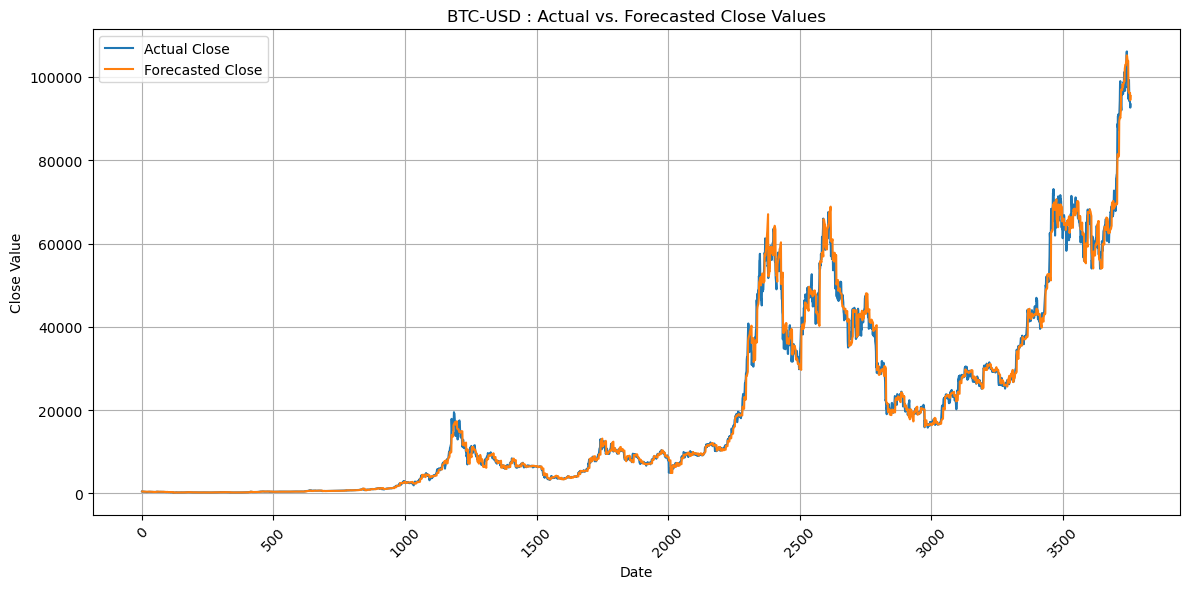

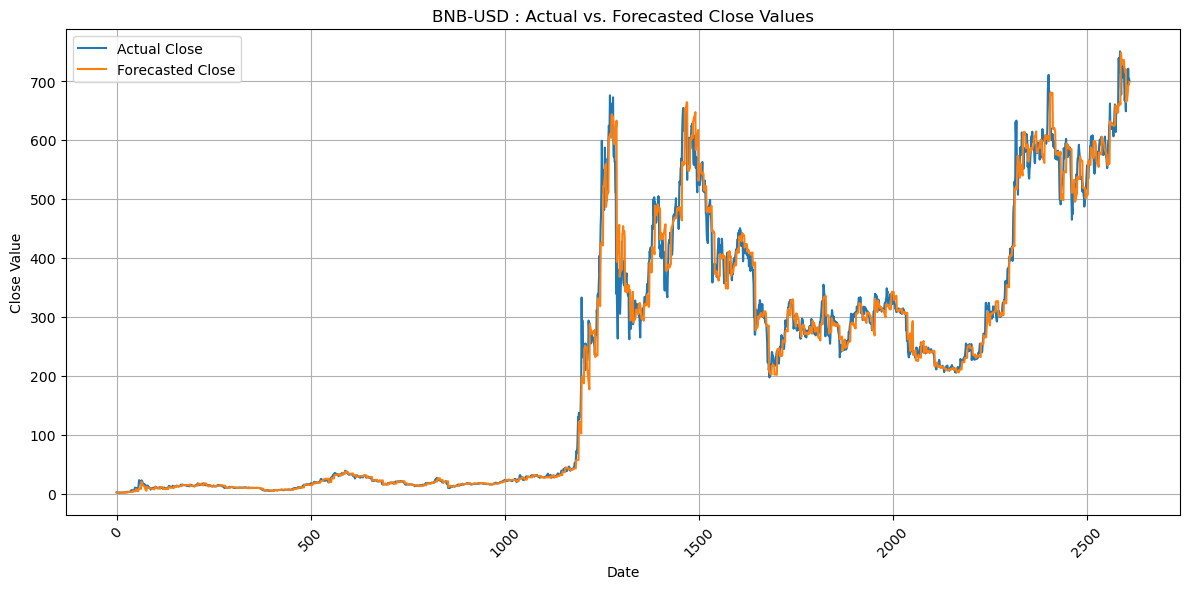

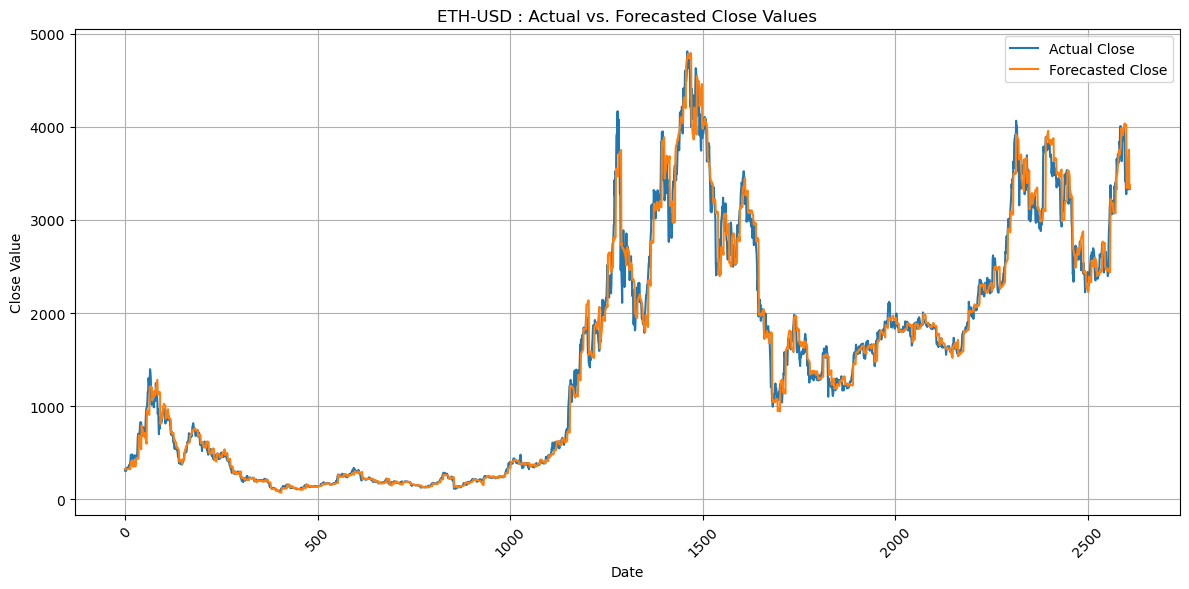

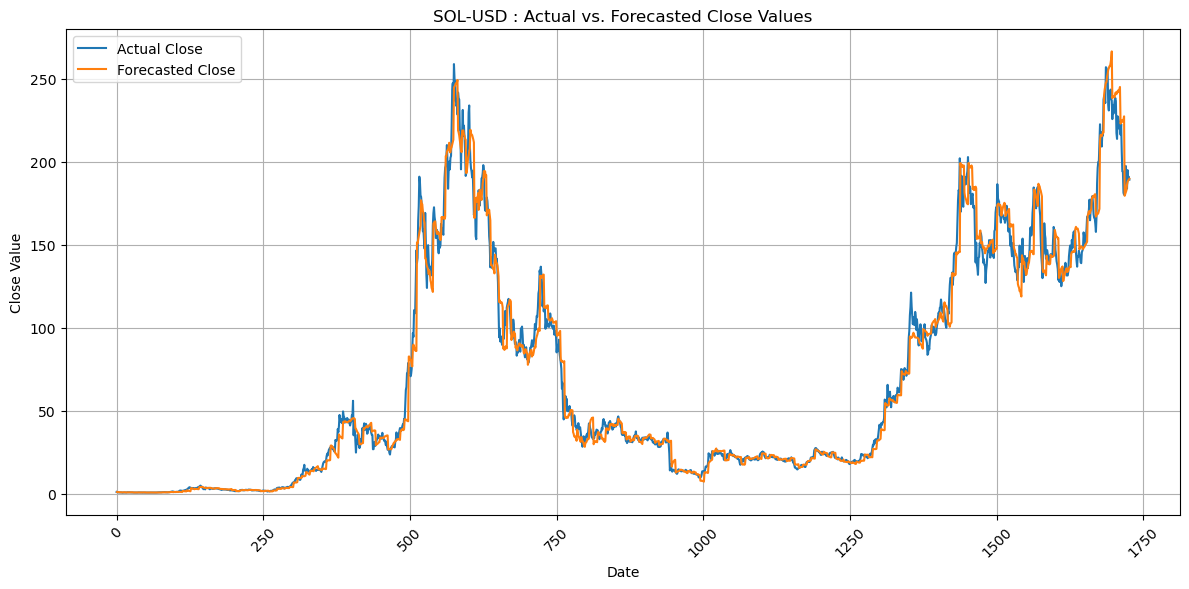

In [4]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
postfix = "timesfm_7_88651c90-12ed-4fd1-8adb-cfcf526c8ae0_forecasts"
for symbol in crypto_symbols:
    forecast_result_path = os.path.join(OUTPUTS_DIR, f"{symbol}_{postfix}.csv")
    forecast_df = pd.read_csv(forecast_result_path)
    plot_actual_vs_forecast_for_a_symbol(symbol, forecast_df)

### Evaluate the forecasts

In [8]:
# Evaluate the forecasts
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results_timesfm_7_v1 = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = "timesfm_7_88651c90-12ed-4fd1-8adb-cfcf526c8ae0"
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results_timesfm_7_v1)
for symbol, metrics in evaluation_results_timesfm_7_v1.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")


Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 4.497101056800144, 'ME': 542.7193440061479, 'MAE': 2954.7562799692623, 'MPE': 0.7708762383815422, 'RMSE': 3757.3204524753146, 'R': 0.9684930334949149, 'Scalar Product': 176404392.85613668, 'Return Score': 0.5095890410958904, 'Long Return': 0.5210526315789473, 'Short Return': 0.49714285714285716, 'Mean Directional Accuracy': 0.5095890410958904, 'Mean Directional Accuracy Positive': 0.5210526315789473, 'Mean Directional Accuracy Negative': 0.49714285714285716}}, 'BNB-USD': {'test': {'MAPE': 4.684283896751118, 'ME': 3.4243736920199344, 'MAE': 25.798054092944202, 'MPE': 0.5461118764444914, 'RMSE': 34.289361649443364, 'R': 0.9536065984564098, 'Scalar Product': -11536.172048045057, 'Return Score': 0.4986301369863014, 'Long Return': 0.4869109947643979, 'Short Return': 0.5114942528735632, 'Mean Directional Accuracy': 0.4986301369863014, 'Mean Directional Accuracy Positive': 0.4869109947643979, 'Mean Directional Accuracy Negative': 0.5114942528

## 30 day forecast

Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='cpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')

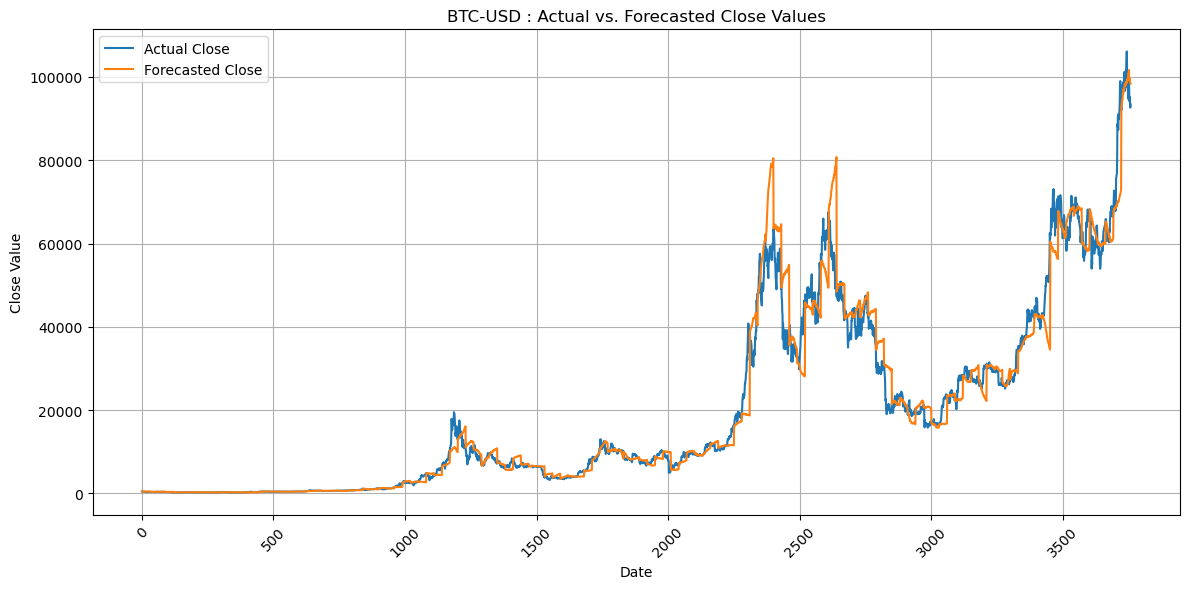

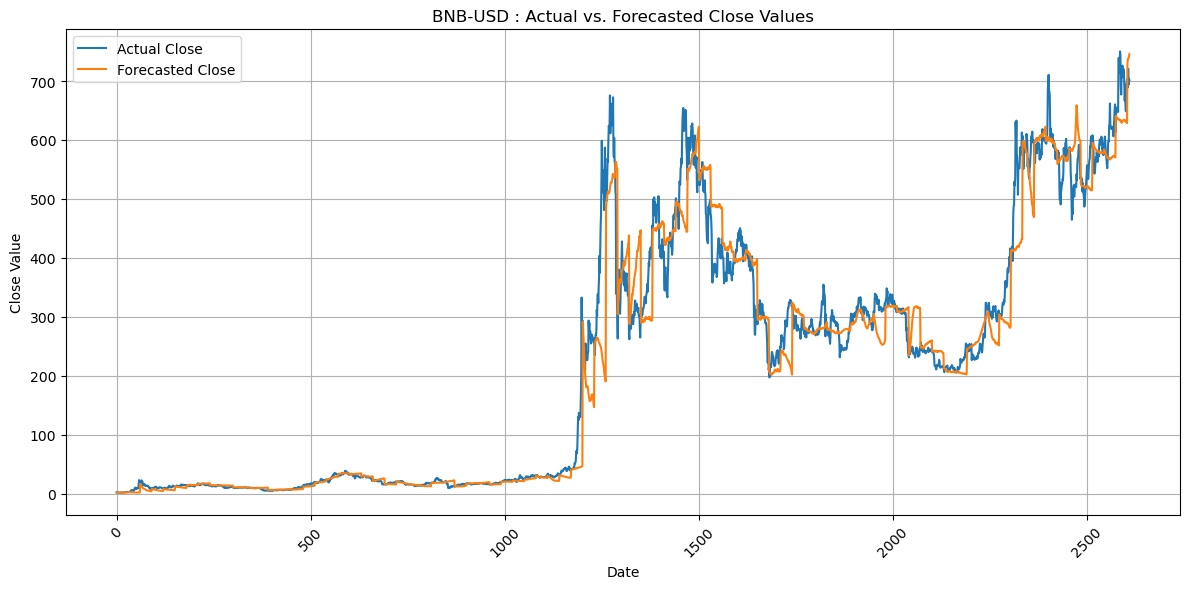

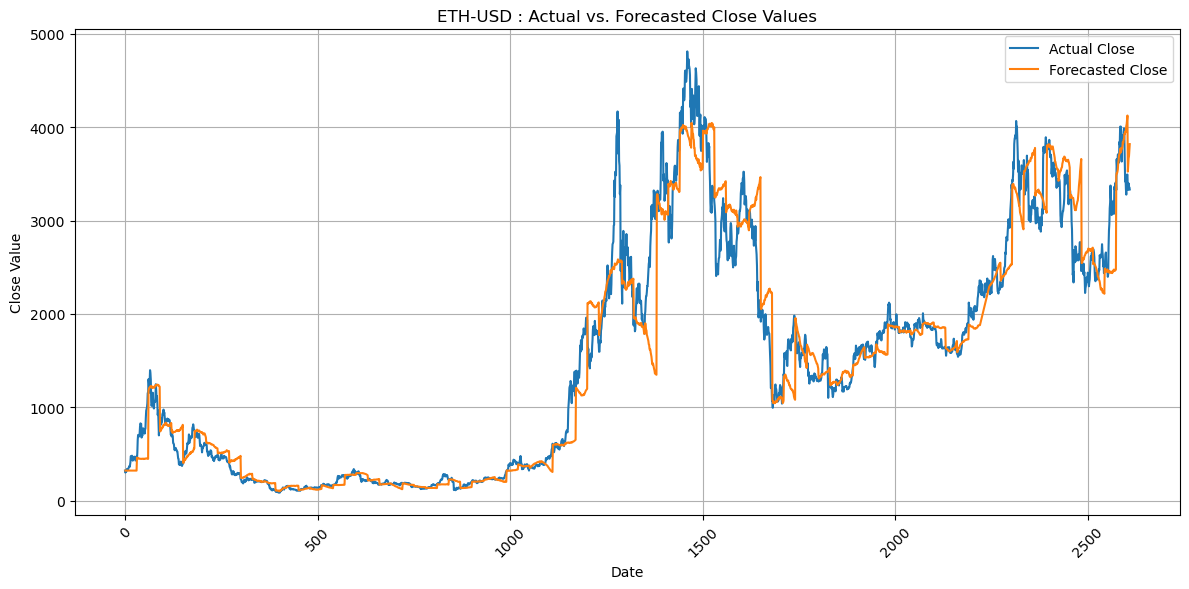

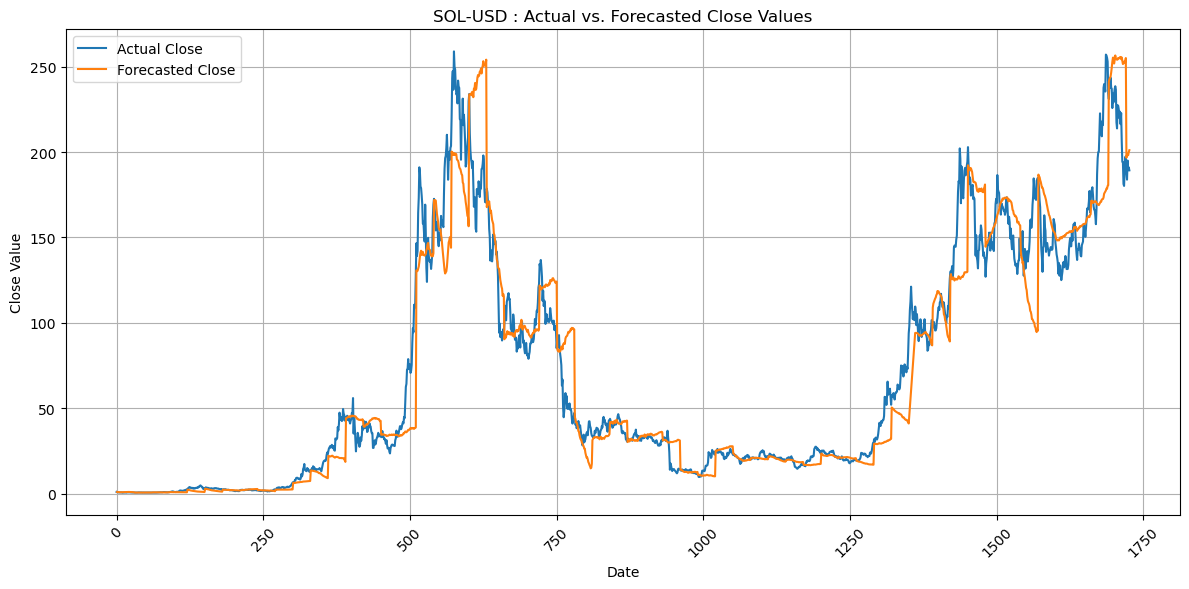

In [13]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
postfix = "timesfm_30_64d270fe-9792-43ef-8cee-332808060380_forecasts"
for symbol in crypto_symbols:
    forecast_result_path = os.path.join(OUTPUTS_DIR, f"{symbol}_{postfix}.csv")
    forecast_df = pd.read_csv(forecast_result_path)
    plot_actual_vs_forecast_for_a_symbol(symbol, forecast_df)

### Evaluate the forecast

In [14]:
# Evaluate the forecasts
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results_timesfm_30_v1 = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = "timesfm_30_64d270fe-9792-43ef-8cee-332808060380"
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results_timesfm_30_v1)
for symbol, metrics in evaluation_results_timesfm_30_v1.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")


Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 7.5776560513143, 'ME': 2684.8950817110654, 'MAE': 5036.94170551571, 'MPE': 3.769859394872912, 'RMSE': 7425.201063470824, 'R': 0.8888154714046753, 'Scalar Product': 31473008.461308733, 'Return Score': 0.5013698630136987, 'Long Return': 0.4105263157894737, 'Short Return': 0.6, 'Mean Directional Accuracy': 0.5013698630136987, 'Mean Directional Accuracy Positive': 0.4105263157894737, 'Mean Directional Accuracy Negative': 0.6}}, 'BNB-USD': {'test': {'MAPE': 8.45695073647744, 'ME': 22.472380905134692, 'MAE': 44.277961567436186, 'MPE': 4.41340241687452, 'RMSE': 60.99792524689348, 'R': 0.8848493522008167, 'Scalar Product': -2015.2915995687845, 'Return Score': 0.5041095890410959, 'Long Return': 0.418848167539267, 'Short Return': 0.5977011494252874, 'Mean Directional Accuracy': 0.5041095890410959, 'Mean Directional Accuracy Positive': 0.418848167539267, 'Mean Directional Accuracy Negative': 0.5977011494252874}}, 'ETH-USD': {'test': {'MAPE': 10.4

## 1 day Forecast

Model used: TimesFmHparams(context_len=128, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')


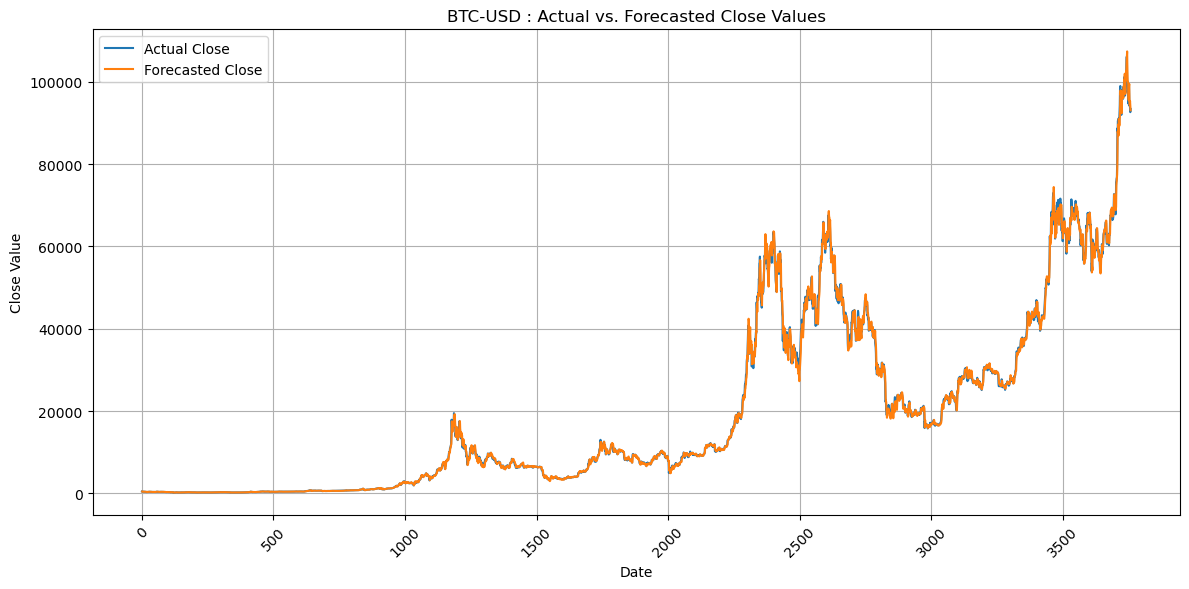

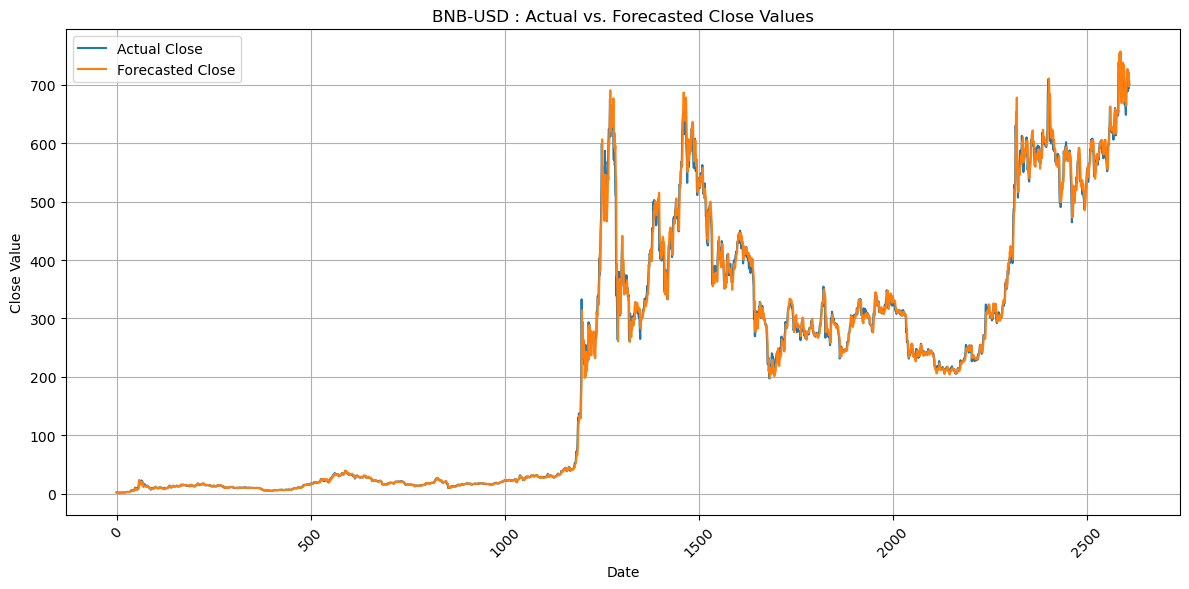

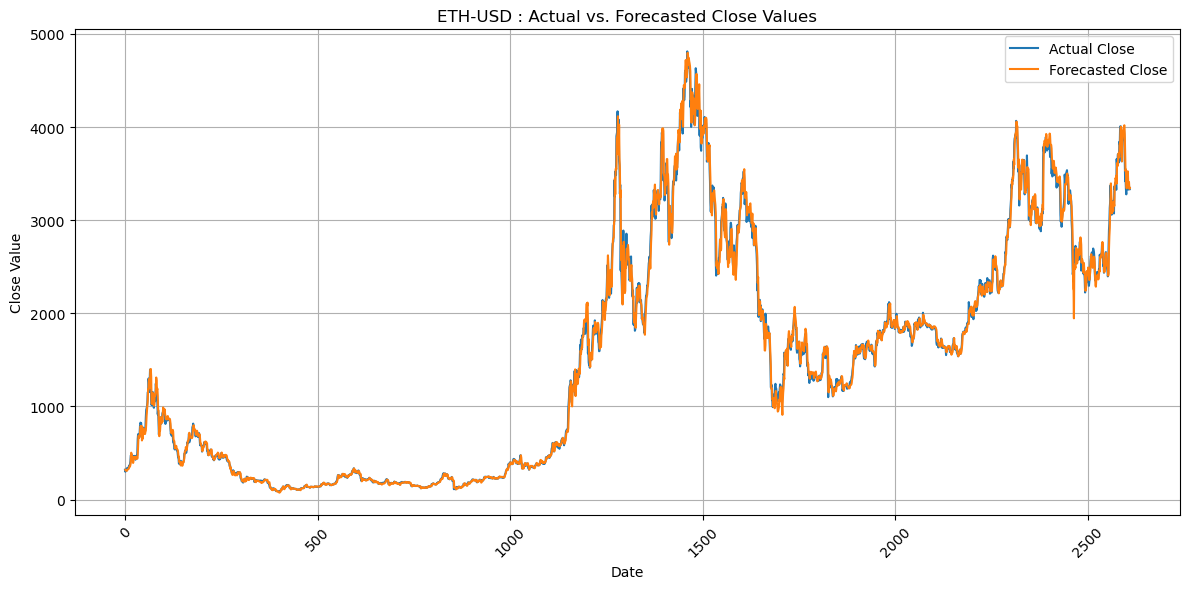

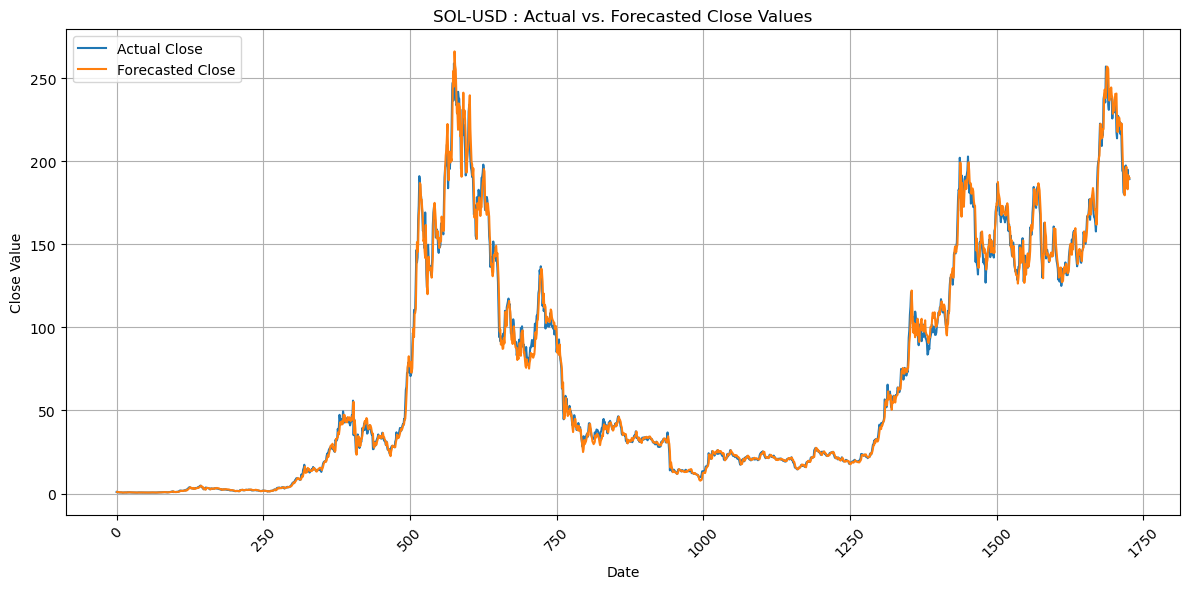

In [10]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']

for symbol in crypto_symbols:
    forecast_result_path = os.path.join(OUTPUTS_DIR, f"{symbol}_timesfm_1_4d29dbb8-18f6-4199-b62b-713ba7acf04f_forecasts.csv")
    forecast_df = pd.read_csv(forecast_result_path)
    plot_actual_vs_forecast_for_a_symbol(symbol, forecast_df)

### Evaluate the results

In [12]:
# Evaluate the forecasts
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
evaluation_results_timesfm_1_v1 = evaluate_forecasts(OUTPUTS_DIR, crypto_symbols, model = "timesfm_1_4d29dbb8-18f6-4199-b62b-713ba7acf04f"
                                        , forecasted_value_col = "Forecasted_Close", actual_value_col = "Close"
                                        , test_data_date = "2024-01-01")

# Print the evaluation results
print("\nEvaluation Results:")
print(evaluation_results_timesfm_1_v1)
for symbol, metrics in evaluation_results_timesfm_1_v1.items():
    print(f"\n--- {symbol} ---")
    print("Test Set Metrics:")
    for metric, value in metrics.get('test', {}).items():
        print(f"{metric}: {value}")
    print("Train Set Metrics:")  # Note: Train set evaluation might be limited with this forecasting approach
    for metric, value in metrics.get('train', {}).items():
        print(f"{metric}: {value}")


Evaluation Results:
{'BTC-USD': {'test': {'MAPE': 2.1754005172147233, 'ME': 147.1675516564209, 'MAE': 1442.8198052424857, 'MPE': 0.19029992060057366, 'RMSE': 1967.4197380560915, 'R': 0.9910795732573364, 'Scalar Product': -38188103.042097606, 'Return Score': 0.4547945205479452, 'Long Return': 0.47368421052631576, 'Short Return': 0.4342857142857143, 'Mean Directional Accuracy': 0.4547945205479452, 'Mean Directional Accuracy Positive': 0.47368421052631576, 'Mean Directional Accuracy Negative': 0.4342857142857143}}, 'BNB-USD': {'test': {'MAPE': 2.451996873496257, 'ME': -1.1933126467778772, 'MAE': 13.417372357010974, 'MPE': -0.26779217102225544, 'RMSE': 18.831027207824608, 'R': 0.9858254664241761, 'Scalar Product': -6610.207419935012, 'Return Score': 0.4794520547945205, 'Long Return': 0.5445026178010471, 'Short Return': 0.40804597701149425, 'Mean Directional Accuracy': 0.4794520547945205, 'Mean Directional Accuracy Positive': 0.5445026178010471, 'Mean Directional Accuracy Negative': 0.4080

In [13]:
evaluation_data = {
    30: evaluation_results_timesfm_30_v1, 7 : evaluation_results_timesfm_7_v1, 1 : evaluation_results_timesfm_1_v1
}

In [17]:
data = []
for horizon, currency_data in evaluation_data.items():
    for currency, metrics in currency_data.items():
        for metric, value in metrics['test'].items():
            data.append([horizon, currency, metric, value])

df = pd.DataFrame(data, columns=['horizon', 'currency', 'metric', 'value'])

# Pivot the table to have metrics as index and horizon/currency as columns
pivot_df = df.pivot_table(index='metric', columns=['currency','horizon'], values='value')

pivot_df

currency                                BNB-USD                             \
horizon                                      1             7            30   
metric                                                                       
Long Return                            0.544503      0.486911     0.418848   
MAE                                   13.417372     25.798054    44.277962   
MAPE                                   2.451997      4.684284     8.456951   
ME                                    -1.193313      3.424374    22.472381   
MPE                                   -0.267792      0.546112     4.413402   
Mean Directional Accuracy              0.479452      0.498630     0.504110   
Mean Directional Accuracy Negative     0.408046      0.511494     0.597701   
Mean Directional Accuracy Positive     0.544503      0.486911     0.418848   
R                                      0.985825      0.953607     0.884849   
RMSE                                  18.831027     34.289362    60.997925   
Return Score                           0.479452      0.498630     0.504110   
Scalar Product                     -6610.207420 -11536.172048 -2015.291600   
Short Return                           0.408046      0.511494     0.597701   

currency                                 BTC-USD                              \
horizon                                       1             7             30   
metric                                                                         
Long Return                         4.736842e-01  5.210526e-01  4.105263e-01   
MAE                                 1.442820e+03  2.954756e+03  5.036942e+03   
MAPE                                2.175401e+00  4.497101e+00  7.577656e+00   
ME                                  1.471676e+02  5.427193e+02  2.684895e+03   
MPE                                 1.902999e-01  7.708762e-01  3.769859e+00   
Mean Directional Accuracy           4.547945e-01  5.095890e-01  5.013699e-01   
Mean Directional Accuracy Negative  4.342857e-01  4.971429e-01  6.000000e-01   
Mean Directional Accuracy Positive  4.736842e-01  5.210526e-01  4.105263e-01   
R                                   9.910796e-01  9.684930e-01  8.888155e-01   
RMSE                                1.967420e+03  3.757320e+03  7.425201e+03   
Return Score                        4.547945e-01  5.095890e-01  5.013699e-01   
Scalar Product                     -3.818810e+07  1.764044e+08  3.147301e+07   
Short Return                        4.342857e-01  4.971429e-01  6.000000e-01   

currency                                  ETH-USD                 \
horizon                                        1              7    
metric                                                             
Long Return                              0.492147       0.549738   
MAE                                     83.172446     178.228487   
MAPE                                     2.741497       5.822204   
ME                                      -7.135669     -11.301763   
MPE                                     -0.222231      -0.498564   
Mean Directional Accuracy                0.473973       0.490411   
Mean Directional Accuracy Negative       0.454023       0.425287   
Mean Directional Accuracy Positive       0.492147       0.549738   
R                                        0.974506       0.902392   
RMSE                                   118.234734     233.372221   
Return Score                             0.473973       0.490411   
Scalar Product                     -147925.579620  231295.977791   
Short Return                             0.454023       0.425287   

currency                                              SOL-USD              \
horizon                                        30          1           7    
metric                                                                      
Long Return                              0.602094    0.563536    0.563536   
MAE                                    317.356171    5.672005   10.618304

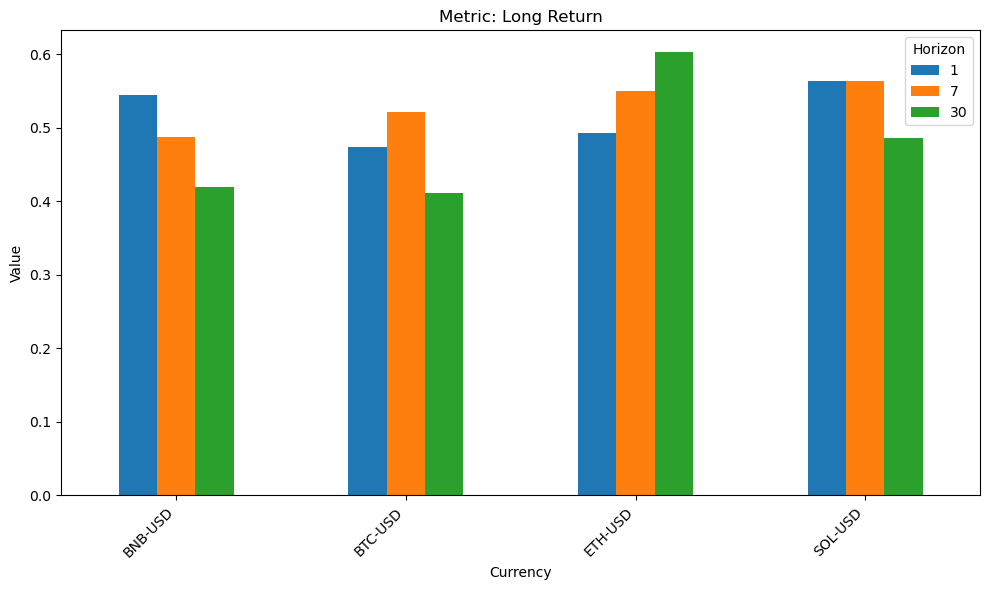

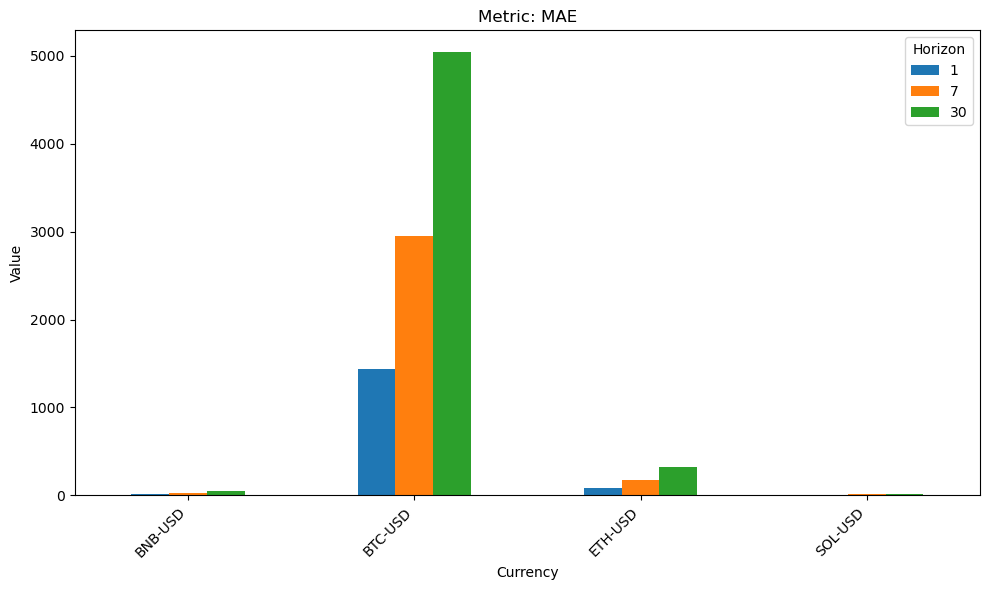

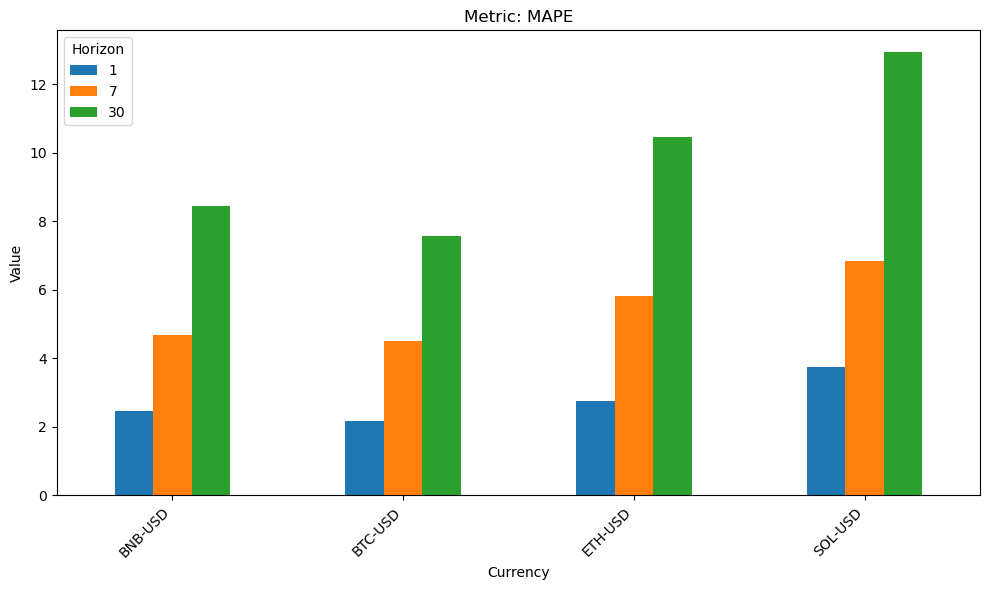

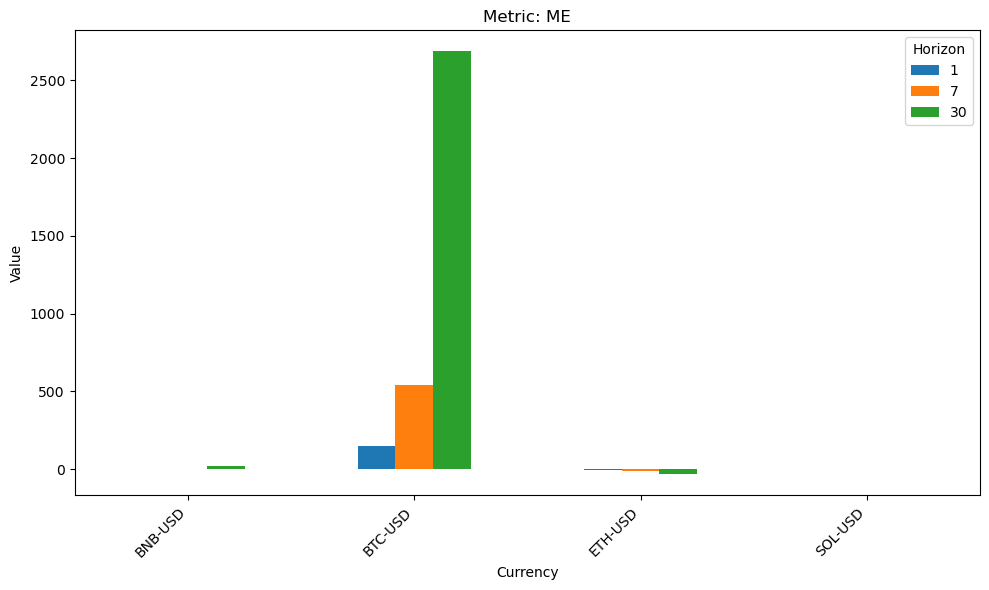

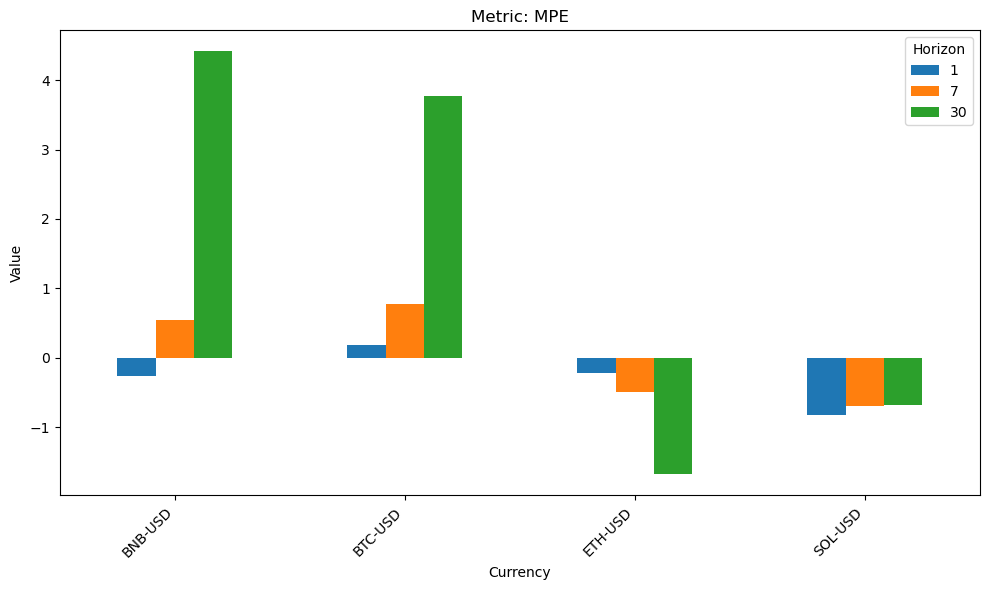

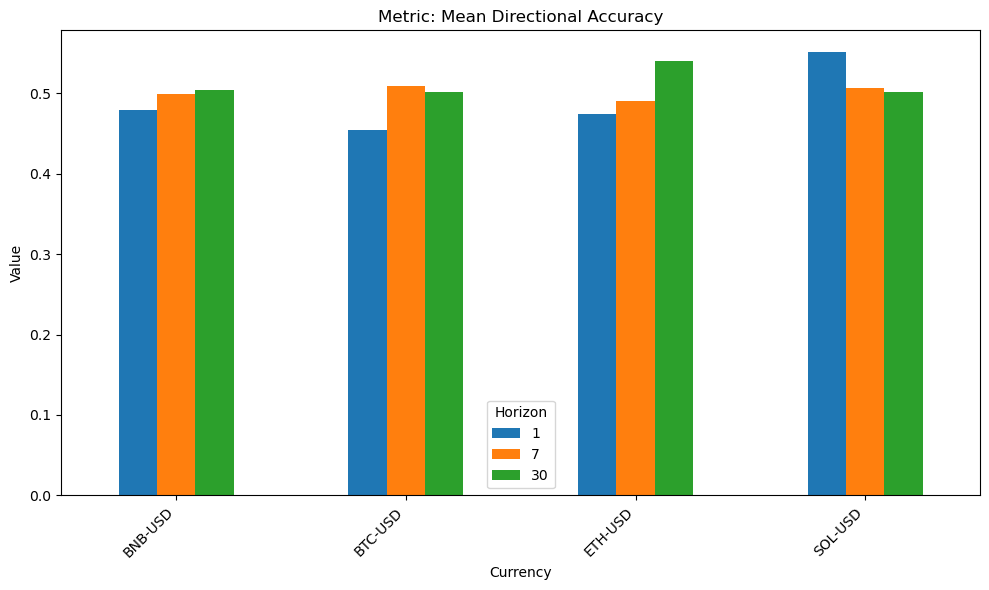

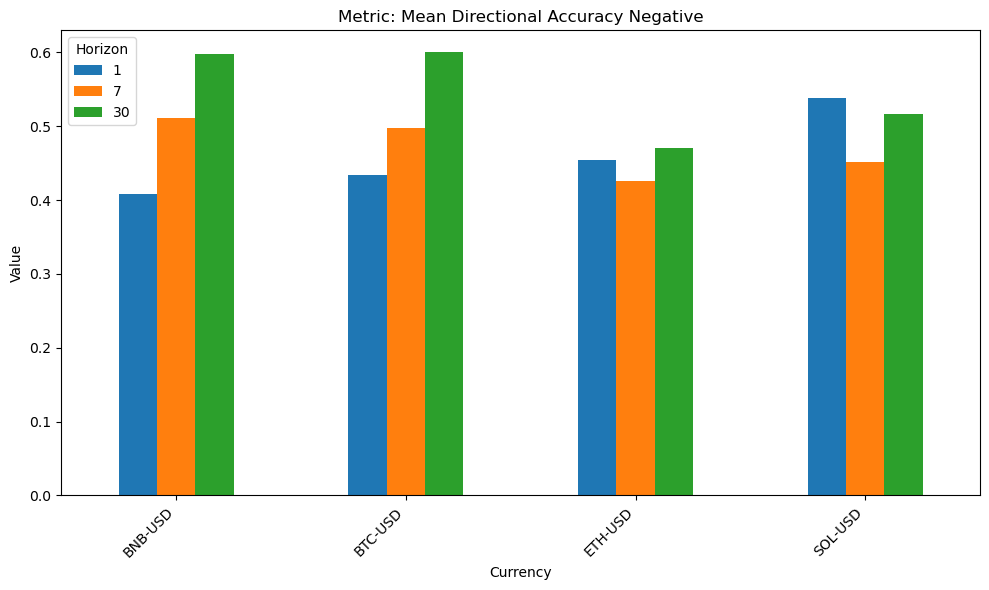

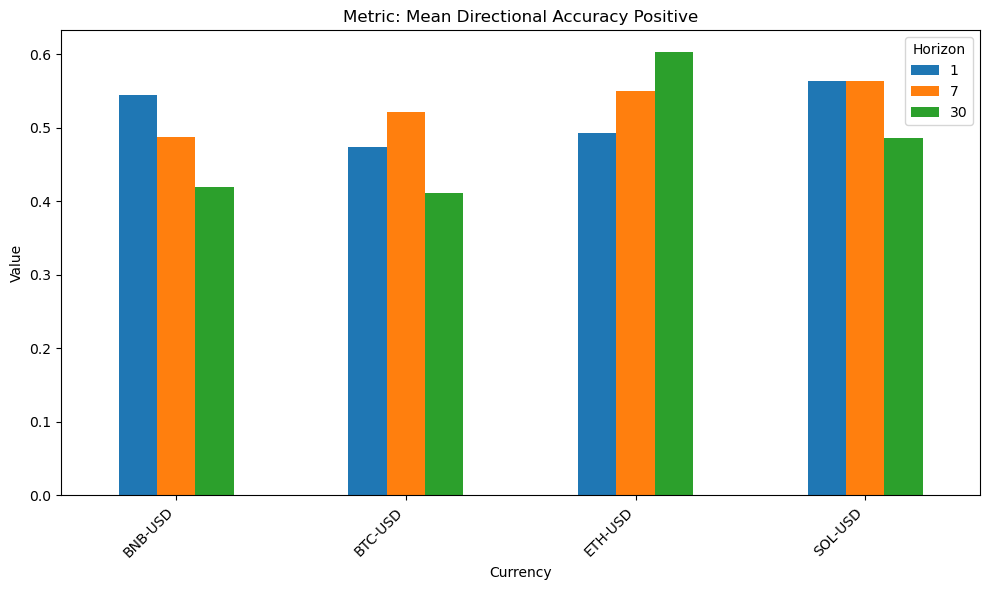

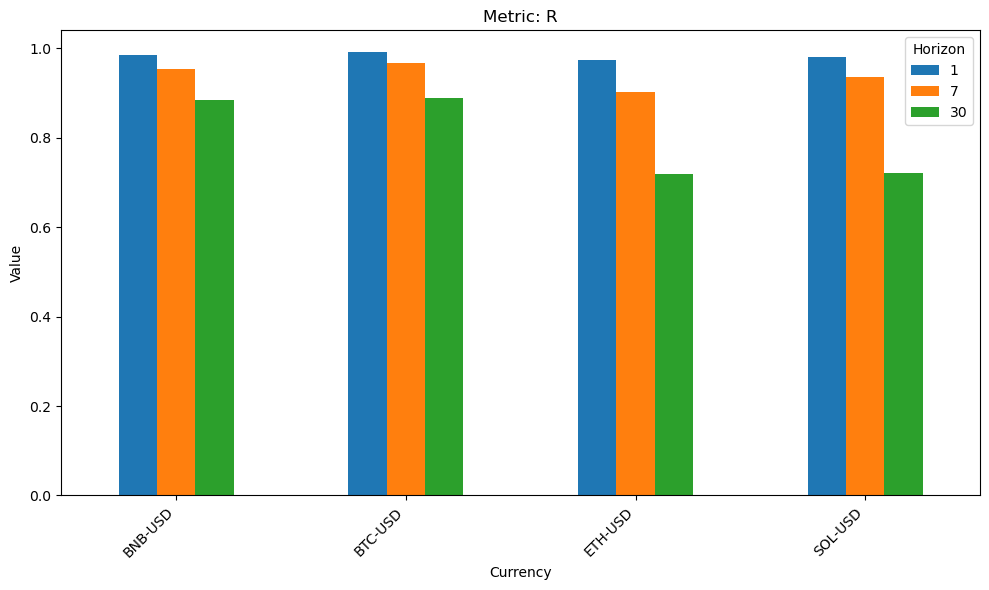

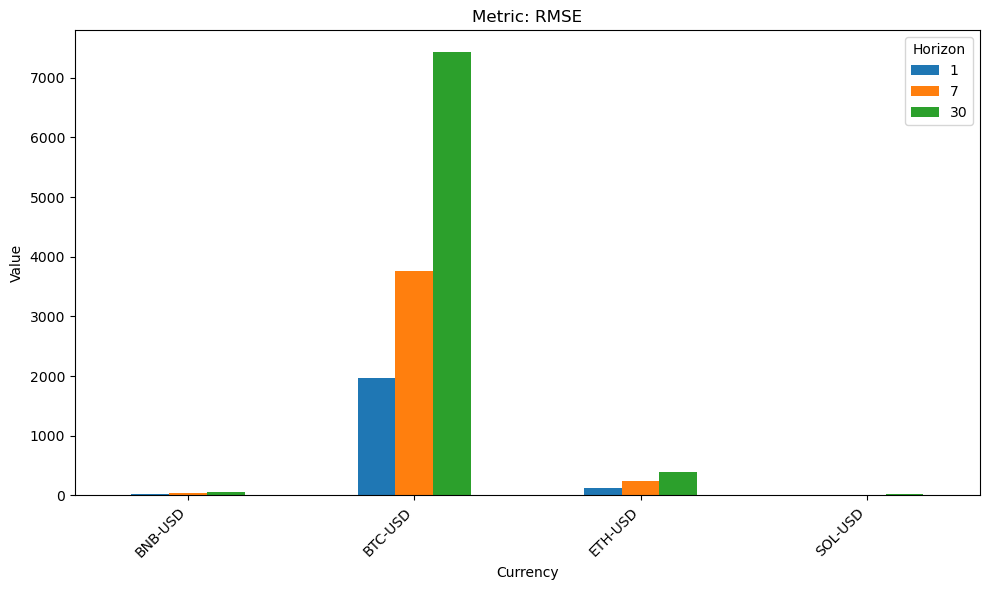

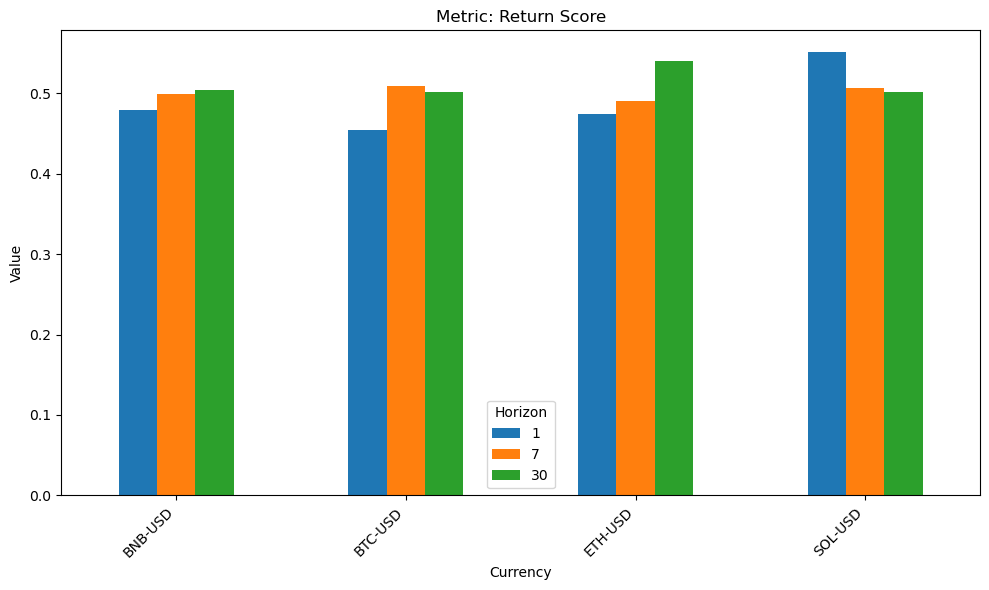

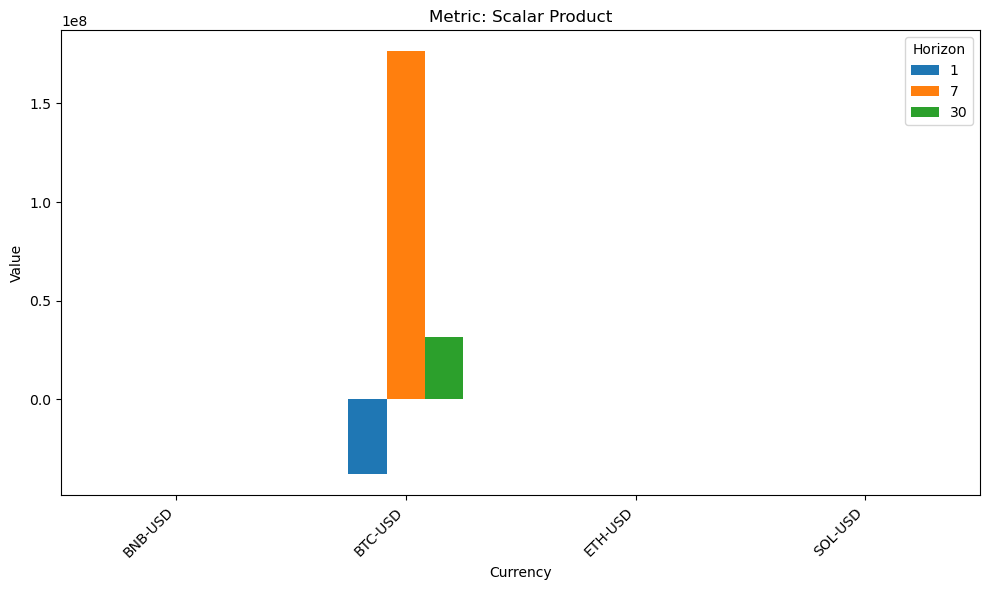

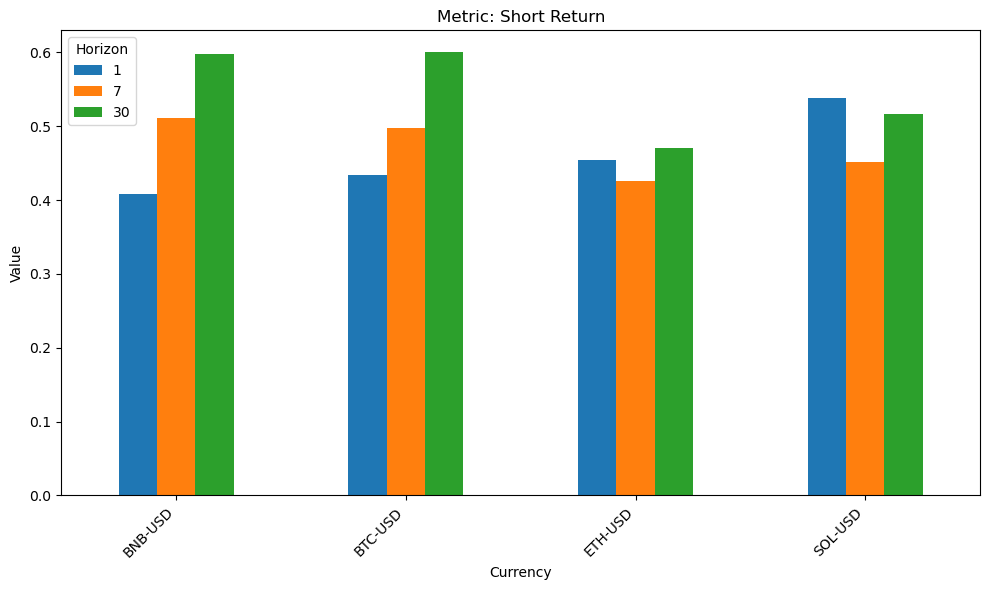

In [19]:
# 2. Grouped Bar Charts (for each metric)
for metric in pivot_df.index:
    metric_data = pivot_df.loc[metric]
    metric_data.unstack().plot(kind='bar', figsize=(10, 6))
    plt.title(f'Metric: {metric}')
    plt.ylabel('Value')
    plt.xlabel('Currency')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Horizon')
    plt.tight_layout()
    plt.show()